# Mosaic integration

**Mosaic integration** has several batches where only **some** share a modality - an RNA-only batch, an ATAC-only batch, and a paired batch that bridges them. Which methods apply depends on the exact per-batch pattern, so `scan()` is the source of truth for each dataset.

**Reference dataset:** `D45` (32,151 cells). The stored results
shipped with these notebooks were produced on it, so every table here
reproduces.

## 1. Install

Two layers: the `multibench` package (~2 MB) and the conda environments of the
methods you run. On **Colab**, run the first cell and let the kernel restart
once - then keep running from the next cell. Sections 2-3 (running methods)
need the environments and a Linux runtime with the disk for them; sections
4-5 (stored results, reference) need only the package.

In [1]:
# Colab ships without conda; this provisions it (the kernel restarts ONCE).
# On a machine that already has conda, this cell does nothing.
import importlib.util, shutil

def _has(mod):
    try:
        return importlib.util.find_spec(mod) is not None
    except ModuleNotFoundError:
        return False

if shutil.which("conda") or shutil.which("mamba"):
    print("conda available - nothing to do")
elif _has("google.colab"):
    !pip -q install condacolab
    import condacolab
    condacolab.install()   # restarts the kernel; afterwards, continue below
else:
    print("no conda found - install it first (mamba recommended); see the installation guide")

conda available - nothing to do


In [2]:
import importlib.util, os
if importlib.util.find_spec("multibench") is None:
    !git clone --depth 1 https://github.com/DSichang/scMultiBench.git
    %cd scMultiBench
    !pip -q install -e .
elif os.path.isdir("/content/scMultiBench"):
    # reused Colab runtime: refresh the editable install to the latest code,
    # then drop the already-imported modules so the NEXT import sees it -
    # a live kernel never re-reads changed files on its own
    %cd /content/scMultiBench
    !git pull -q
    !pip -q install -e .
    import importlib, sys
    for _m in [m for m in list(sys.modules) if m == "multibench" or m.startswith("multibench.")]:
        del sys.modules[_m]
    importlib.invalidate_caches()
    print("multibench refreshed to the latest repository state")
else:
    print("multibench already installed")

multibench already installed


Now the environments for the methods this tutorial runs
(StabMap, scMoMaT). `--packed` downloads a prebuilt archive (2-14 GB
per environment) instead of solving one from scratch, and `env install` skips
anything already present. Other tiers are one flag away: `--category mosaic`
(~45 GB (7 envs)), or no flag for the whole benchmark (29 envs, ~167 GB).

In [3]:
import sys
!{sys.executable} -m multibench env install --methods StabMap,scMoMaT --packed --run

scmb_r             [have          ] <- StabMap
scmb_torch         [have          ] <- scMoMaT


In [4]:
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
from pathlib import Path
import pandas as pd
pd.set_option("display.max_colwidth", None)   # never truncate a `reason`
pd.set_option("display.max_columns", None)    # never hide a metric column
pd.set_option("display.width", 200)
import multibench as mtb

DATASET  = "D45"
CATEGORY = "mosaic"
mtb.data.fetch('D45', 'D46')   # reference data (290 MB, 97 MB); no-op when present
print("multibench", mtb.__version__)

multibench 0.2.1


## 2. Run the analysis

One call is the whole pipeline: resolve each method's inputs, run it in its own
conda env, load the embeddings, score them with scIB metrics. Here
StabMap, scMoMaT (on `D46`, whose layout fits these methods; mosaic layouts vary per dataset). Both run in minutes to tens of minutes on D46 - `run_sec` in the summary is the measured time on our host.

In [5]:
res = mtb.run_all("D46", CATEGORY,
                  methods=['StabMap', 'scMoMaT'],
                  out_dir="/tmp/tutorial_mosaic")
res.summary

[run_all] StabMap (mosaic/D46) ...


[run_all]   -> CHAIN_OK (80.8s) 0.574


[run_all] scMoMaT (mosaic/D46) ...


[run_all]   -> CHAIN_OK_GRAPH_METHOD (209.3s) 0.2817


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,ARI,NMI,ASW,iASW,iF1,cLISI,ASW_batch,GC,iLISI,label_order_note
0,StabMap,CHAIN_OK,80.8,embedding,"[21416, 50]",0,cty1.csv+cty2.csv+cty3.csv,0.5517,file_of_origin,3,0.5740,0.7291,0.5426,0.5313,0.4882,0.9944,0.8100,0.9545,0.0273,None
1,scMoMaT,CHAIN_OK_GRAPH_METHOD,209.3,graph,"[21416, 2]",0,cty1.csv+cty2.csv+cty3.csv,0.8356,file_of_origin,3,0.2817,0.5446,0.4152,0.3471,0.3415,0.9882,0.4944,0.4239,0.1250,None


`summary` is sorted by method name, whatever order `methods=` listed;
`emb_shape` is the embedding each method produced and `batch_source` says which
batch vector the batch metrics used.  The result object plots
itself in the paper's layout:

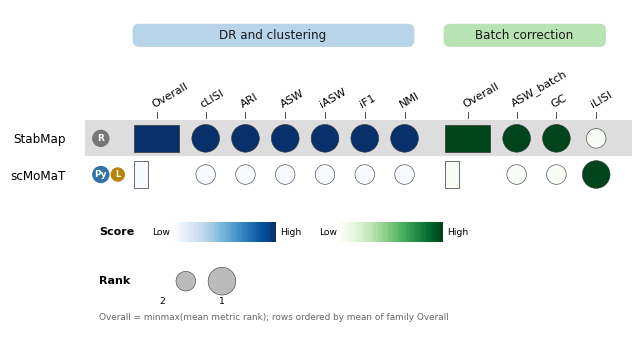

In [6]:
res.plot()

Each circle carries two encodings: its **size is the method's rank** in
that column (largest = rank 1) and its **colour is the metric's value**, min-max
scaled within the column (darker = higher). Columns are grouped by task family -
blues for DR & clustering, greens for batch correction - and each family is led
by an **Overall** rank column, where bar length and colour carry the same two
encodings.

## 3. Your own data

The same three calls - `scan`, `run_all`, `plot` - on a folder the package has
never seen. A dataset is a folder of flat files named by category:

In [7]:
print(mtb.describe_layout(CATEGORY))

Put your files in  <data_path>/<DATASET_NAME>/ , e.g. ./data/MYDATA/
  (dataset = the folder NAME; data_path = the folder that CONTAINS it)

LAYOUT FOR MOSAIC:
  rna1.h5 rna2.h5 atac2.h5 atac3.h5   <- numbered, one per batch
  cty1.csv cty2.csv cty3.csv          <- one per batch

  (numbered files live in the SAME flat dir; there is no batch column)

Modality roles and the filenames they resolve to:
    rna              rna.h5      - gene expression
    adt              adt.h5      - surface protein (CITE-seq antibody-derived tags)
    atac             atac.h5     - chromatin accessibility
    atac_gas         atac.h5     - ATAC as GENE-ACTIVITY scores  <-- note: plain atac.h5
    atac_peak        peak.h5     - ATAC as PEAKS                 <-- note: peak.h5, NOT atac.h5
    rna1/rna2/...    rna1.h5, rna2.h5, ... - one file per BATCH (mosaic/cross)
    adt1/adt2/...    adt1.h5, adt2.h5, ... - one file per BATCH (mosaic/cross)
    cty              cty.csv     - cell-type labels, ONE lab

Each modality file is HDF5 with three datasets:

| dataset | contents | shape |
|---|---|---|
| `matrix/data` | the matrix, **features x cells** | `(n_features, n_cells)` |
| `matrix/features` | one name per feature | `(n_features,)` |
| `matrix/barcodes` | one id per cell | `(n_cells,)` |

That is the **transpose** of the AnnData convention (`AnnData.X` is cells x
genes); the `mtb.io` writers below handle it, and `scan()` rejects a transposed
file at preflight rather than letting a method fail half an hour in. The label
CSV is a **single column** with one header line (typically `x`) and one label
per cell, in the same order as `matrix/barcodes` of the matching modality file.
For ATAC, check which representation a method wants - gene-activity scores or
peaks - because the wrong one runs to completion and returns a plausible but
wrong embedding. The shipped label files, as `evaluate` will read them:

In [8]:
labels = mtb.labels_for(DATASET)            # {stem: path} - what the metrics are scored against
print({k: Path(v).name for k, v in labels.items()})
print(*Path(next(iter(labels.values()))).read_text().splitlines()[:4], sep="\n")

{'cty1': 'cty1.csv', 'cty2': 'cty2.csv', 'cty3': 'cty3.csv'}
"x"
"CD4 Naive"
"CD4 Memory"
"CD4 Naive"


Writing that layout from AnnData objects, executed here on a synthetic
example - sparse matrices stream without densifying, and the folder passes the
same file gate `scan` applies to the shipped datasets:

In [9]:
import anndata as ad, numpy as np, tempfile, os
rng = np.random.default_rng(0)
def batch(n):
    a = ad.AnnData(X=rng.poisson(1.0, size=(n, 40)).astype(float)); a.var_names = [f"gene{i}" for i in range(40)]
    a.obs["celltype"] = rng.choice(["T", "B", "NK"], n); return a
b1, b2, b3 = batch(100), batch(80), batch(60)                                  # three batches, D46's pattern:
b1.obsm["protein"] = rng.poisson(3.0, size=(100, 12)).astype(float)           #   batch 1 = RNA + ADT
b2.obsm["peaks"]   = rng.poisson(0.3, size=(80, 50)).astype(float)            #   batch 2 = RNA + ATAC, batch 3 = RNA only

folder = os.path.join(tempfile.mkdtemp(), "MYMOSAIC"); os.makedirs(folder)
for i, a in enumerate([b1, b2, b3], start=1):
    mtb.io.to_canonical(a, os.path.join(folder, f"rna{i}.h5"))
    mtb.io.write_labels(a.obs["celltype"], os.path.join(folder, f"cty{i}.csv"))
mtb.io.to_canonical(b1, os.path.join(folder, "adt1.h5"),  modality="adt",  obsm="protein")
mtb.io.to_canonical(b2, os.path.join(folder, "atac2.h5"), modality="atac", obsm="peaks")
print(sorted(os.listdir(folder)))
sc = mtb.scan("MYMOSAIC", CATEGORY, data_path=os.path.dirname(folder))
print(f"{int(sc.files_ok.sum())} of {len(sc)} method variants pass the file gate - the per-batch pattern decides which")

['adt1.h5', 'atac2.h5', 'cty1.csv', 'cty2.csv', 'cty3.csv', 'rna1.h5', 'rna2.h5', 'rna3.h5']
2 of 7 method variants pass the file gate - the per-batch pattern decides which


Now a real dataset the package has never seen: a 60% cell subsample of
`D46` under a new name, built with ordinary h5py/pandas code so the
per-file rule (matching files keep the same cell index) is visible.

In [10]:
import os, shutil
import h5py
import numpy as np
import pandas as pd

def subsample_dataset(src_dir, dst_dir, frac=0.6, seed=0):
    """Copy a dataset to a new name, keeping a random fraction of the cells.

    Files sharing a cell count get the SAME kept-cell index, so modality files
    and their label CSVs stay aligned - which is exactly the property your own
    export pipeline must preserve. The output is the canonical layout:
    matrix/data as features x cells, plus matrix/features and matrix/barcodes.
    """
    rng = np.random.default_rng(seed)
    os.makedirs(dst_dir, exist_ok=True)
    counts, keep = {}, {}
    for fn in sorted(os.listdir(src_dir)):
        p = os.path.join(src_dir, fn)
        if fn.endswith(".h5"):
            with h5py.File(p) as f:
                if "matrix/data" in f:
                    counts[fn] = f["matrix/data"].shape[1]   # features x cells
        elif fn.endswith(".csv"):
            counts[fn] = len(pd.read_csv(p))
    for n in set(counts.values()):
        k = max(50, int(n * frac))
        keep[n] = np.sort(rng.choice(n, size=k, replace=False))
    for fn, n in counts.items():
        sp, dp = os.path.join(src_dir, fn), os.path.join(dst_dir, fn)
        idx = keep[n]
        if fn.endswith(".csv"):
            pd.read_csv(sp).iloc[idx].to_csv(dp, index=False)
        else:
            with h5py.File(sp) as f, h5py.File(dp, "w") as g:
                grp = g.create_group("matrix")
                grp.create_dataset("data", data=np.asarray(f["matrix/data"])[:, idx])
                if "matrix/features" in f:
                    grp.create_dataset("features", data=np.asarray(f["matrix/features"]))
                if "matrix/barcodes" in f:
                    grp.create_dataset("barcodes", data=np.asarray(f["matrix/barcodes"])[idx])
    return dst_dir

`scan` checks two independent gates per method: `files_ok` - the folder
itself (files present, features x cells orientation, one label per cell) - and
`env_ok` - that method's conda environment exists on this machine. `runnable`
is both; `reason` says which failed and how to fix it. The file gate runs
anywhere, so a laptop without a single environment still tells you whether your
layout is right.

In [11]:
DATA_ROOT = "/tmp/mydata"
src = mtb.config.DEFAULT.data_path / "D46"
subsample_dataset(src, f"{DATA_ROOT}/MYDATA_mosaic", frac=0.6)

sc = mtb.scan(f"MYDATA_mosaic", category=CATEGORY, data_path=DATA_ROOT)
print(f"files_ok {int(sc.files_ok.sum())}, env_ok {int(sc.env_ok.sum())}, runnable {int(sc.runnable.sum())} of {len(sc)} method variants")
sc[["method", "modalities", "files_ok", "env_ok", "runnable", "reason"]].head(6)

files_ok 2, env_ok 7, runnable 2 of 7 method variants


,method,modalities,files_ok,env_ok,runnable,reason
0,StabMap,rna1+rna2+rna3+adt1+atac2,True,True,True,
1,scMoMaT,rna1+rna2+rna3+adt1+atac2,True,True,True,
2,Cobolt,rna1+rna2+atac2+atac3,False,True,False,"FileNotFoundError: Cobolt/MYDATA_mosaic/mosaic: input files not found on disk: {'atac3': '/tmp/mydata/MYDATA_mosaic/atac3.h5'}. Available files in /tmp/mydata/MYDATA_mosaic: ['adt1.h5', 'atac2.h5', 'cty1.csv', 'cty2.csv', 'cty3.csv', 'rna1.h5', 'rna2.h5', 'rna3.h5']"
3,MultiVI,rna1+atac3+rna2+atac2,False,True,False,"FileNotFoundError: MultiVI/MYDATA_mosaic/mosaic: input files not found on disk: {'atac3': '/tmp/mydata/MYDATA_mosaic/atac3.h5'}. Available files in /tmp/mydata/MYDATA_mosaic: ['adt1.h5', 'atac2.h5', 'cty1.csv', 'cty2.csv', 'cty3.csv', 'rna1.h5', 'rna2.h5', 'rna3.h5']"
4,Multigrate,rna1+rna2+adt2+adt3,False,True,False,"FileNotFoundError: Multigrate/MYDATA_mosaic/mosaic: input files not found on disk: {'adt2': '/tmp/mydata/MYDATA_mosaic/adt2.h5', 'adt3': '/tmp/mydata/MYDATA_mosaic/adt3.h5'}. Available files in /tmp/mydata/MYDATA_mosaic: ['adt1.h5', 'atac2.h5', 'cty1.csv', 'cty2.csv', 'cty3.csv', 'rna1.h5', 'rna2.h5', 'rna3.h5']"
5,Multigrate,rna1+rna2+atac2+atac3,False,True,False,"FileNotFoundError: Multigrate/MYDATA_mosaic/mosaic: input files not found on disk: {'atac3': '/tmp/mydata/MYDATA_mosaic/atac3.h5'}. Available files in /tmp/mydata/MYDATA_mosaic: ['adt1.h5', 'atac2.h5', 'cty1.csv', 'cty2.csv', 'cty3.csv', 'rna1.h5', 'rna2.h5', 'rna3.h5']"


In [12]:
mine = mtb.run_all(f"MYDATA_mosaic", CATEGORY,
                   methods=['StabMap', 'scMoMaT'],
                   out_dir=f"{DATA_ROOT}/out_mosaic",
                   data_path=DATA_ROOT)
mine.summary

[run_all] StabMap (mosaic/MYDATA_mosaic) ...


[run_all]   -> CHAIN_OK (38.3s) 0.5597


[run_all] scMoMaT (mosaic/MYDATA_mosaic) ...


[run_all]   -> CHAIN_OK_GRAPH_METHOD (131.4s) 0.1995


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,ARI,NMI,ASW,iASW,iF1,cLISI,ASW_batch,GC,iLISI,label_order_note
0,StabMap,CHAIN_OK,38.3,embedding,"[12849, 50]",0,cty1.csv+cty2.csv+cty3.csv,0.5314,file_of_origin,3,0.5597,0.7285,0.5388,0.5288,0.4869,0.9920,0.8071,0.9588,0.0500,None
1,scMoMaT,CHAIN_OK_GRAPH_METHOD,131.4,graph,"[12849, 2]",0,cty1.csv+cty2.csv+cty3.csv,0.7053,file_of_origin,3,0.1995,0.5267,0.3802,0.3400,0.3259,0.9841,0.4627,0.4544,0.1357,None


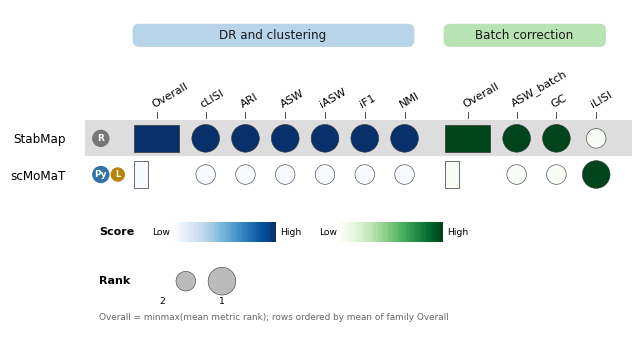

In [13]:
mine.plot()

Both reached CHAIN_OK on this subsample when we ran them. Two methods rather than three because that is every wired mosaic method D46's layout admits - the four-method D45 figures below are where this category's methods are compared side by side. For your real data the only work is producing the
canonical files - `mtb.io.export_dataset` from an AnnData / MuData, or
`to_canonical` + `write_labels` file by file as above - and these same three
calls do the rest.

## 4. Reading stored results

Section 2 ran two methods; the package ships the **full sweep** for `D45` -
every wired method at default settings, hours of compute - so the paper's
figures reproduce from stored results in seconds. `load_results` reads them
back as the tidy frame `mtb.plot.bubble` takes; `source="rerun"` selects the
package's own re-execution (the tables behind this notebook), `"published"`
the paper's tables, and every row says which it came from in its `source`
column.

4 methods, ['rerun-0.2.1']


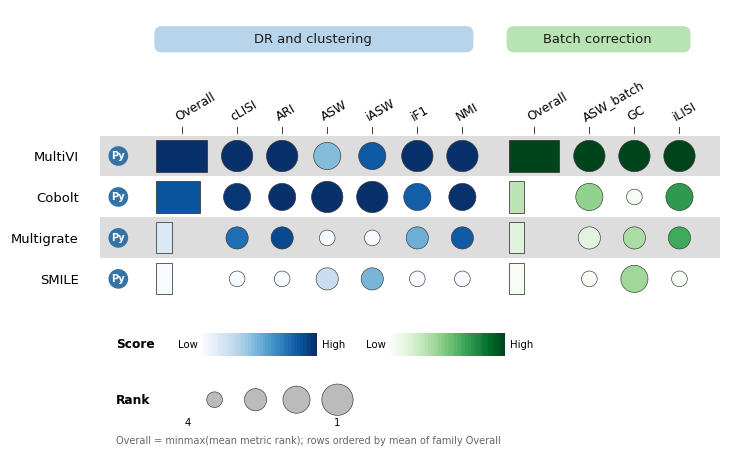

In [14]:
long = mtb.load_results(CATEGORY, dataset=DATASET, source="rerun")
print(long.method.nunique(), "methods,", long.source.unique())
fig = mtb.plot.bubble(long)
fig.set_dpi(110)
fig

`run_all(DATASET, CATEGORY, out_dir=...)` without `methods=` writes the
same `summary.csv` and `long.csv` for your own data; `mtb.load_batch(out_dir)`
reads them back.

**Across datasets.** A summary needs every method to have results on every
dataset it averages over, or absence and performance blur into the same bar. Two
mosaic datasets therefore ship swept identically - `D45` and `D45s` (a 60% cell
subsample of `D45` under a new name) - and `require_complete=True` keeps only
the methods present on both, so the matrix is complete by construction. Each
bar is the **grand rank**: the min-max scaled mean rank across the datasets,
with length and colour both carrying it, and `Overall` is the same statistic
over the grand ranks. Both metric families appear because both datasets are multi-batch.

{'D45': 4, 'D45s': 4}


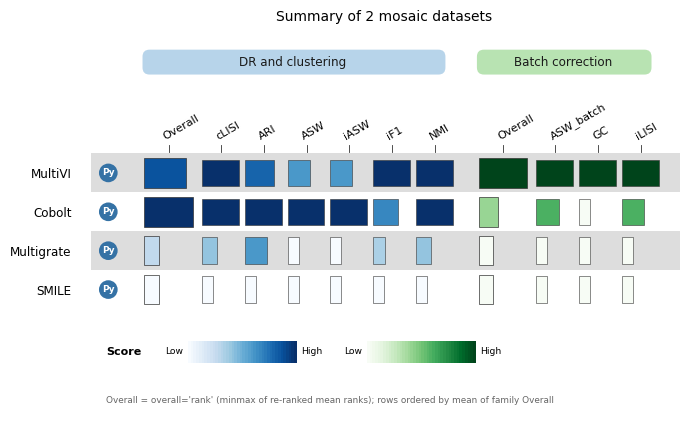

In [15]:
pair = mtb.load_results(CATEGORY, dataset=[DATASET, DATASET + "s"], source="rerun")
print(pair.groupby("dataset").method.nunique().to_dict())
mtb.plot.bubble(pair, aggregate="summary", require_complete=True,
                title=f"Summary of 2 mosaic datasets")

**Published vs re-run.** The paper's own tables (`source="published"`)
and the package's re-runs can differ for a method - methods are stochastic and
the published sweep ran on other hardware - so cite the published numbers and
use the re-runs to check reproducibility; compare ranks, not decimals.
`results_coverage` says what exists for this dataset and where it came from:

In [16]:
cov = mtb.results_coverage(CATEGORY)
cov[cov.dataset == DATASET].groupby("source").method.nunique()

source
rerun-0.2.1    4
Name: method, dtype: int64

## 5. Reference

### What runs on a dataset, and why not

`scan` inspects a folder and reports every runnable method - and for the rest,
the exact reason (missing file, missing environment, wrong layout). Nothing
executes.

In [17]:
avail = mtb.scan(DATASET, category=CATEGORY)
avail[avail.runnable][["method", "modalities", "env", "output_kind",
                       "n_tunable", "needs_labels", "runtime_tier"]]

,method,modalities,env,output_kind,n_tunable,needs_labels,runtime_tier
0,Cobolt,rna1+rna2+atac2+atac3,scmb_cobolt3,embedding,2,False,slow
1,MultiVI,rna1+atac3+rna2+atac2,scmb_multivi,embedding,0,False,very_slow
2,Multigrate,rna1+rna2+atac2+atac3,scmb_multigrate2,embedding,2,False,very_slow
3,SMILE,rna2+atac2+rna1+atac3,env_sciPENN,embedding,0,False,slow


In [18]:
not_ok = avail[~avail.runnable][["method", "modalities", "files_ok", "env_ok", "reason"]]
not_ok.head(5) if len(not_ok) else "(everything in this category runs here)"


,method,modalities,files_ok,env_ok,reason
4,Multigrate,rna1+rna2+adt2+adt3,False,True,"FileNotFoundError: Multigrate/D45/mosaic: input files not found on disk: {'adt2': '/media/disk2/Sichang/scmbench_pkg/data/D45/adt2.h5', 'adt3': '/media/disk2/Sichang/scmbench_pkg/data/D45/adt3.h5'}. Available files in /media/disk2/Sichang/scmbench_pkg/data/D45: ['D45.zip', 'atac2.h5', 'atac3.h5', 'cty1.csv', 'cty2.csv', 'cty3.csv', 'rna1.h5', 'rna2.h5']"
5,StabMap,rna1+rna2+rna3+adt1+atac2,False,True,"FileNotFoundError: StabMap/D45/mosaic: input files not found on disk: {'rna3': '/media/disk2/Sichang/scmbench_pkg/data/D45/rna3.h5', 'adt1': '/media/disk2/Sichang/scmbench_pkg/data/D45/adt1.h5'}. Available files in /media/disk2/Sichang/scmbench_pkg/data/D45: ['D45.zip', 'atac2.h5', 'atac3.h5', 'cty1.csv', 'cty2.csv', 'cty3.csv', 'rna1.h5', 'rna2.h5']"
6,scMoMaT,rna1+rna2+rna3+adt1+atac2,False,True,"FileNotFoundError: scMoMaT/D45/mosaic: input files not found on disk: {'rna3': '/media/disk2/Sichang/scmbench_pkg/data/D45/rna3.h5', 'adt1': '/media/disk2/Sichang/scmbench_pkg/data/D45/adt1.h5'}. Available files in /media/disk2/Sichang/scmbench_pkg/data/D45: ['D45.zip', 'atac2.h5', 'atac3.h5', 'cty1.csv', 'cty2.csv', 'cty3.csv', 'rna1.h5', 'rna2.h5']"


### What each method exposes for tuning

`method_info(m)["supports"]` lists a method's variants with how many
hyperparameters each exposes on its command line; `mtb.params_for(m, CATEGORY,
modalities)` names them. An empty `tunable` is honest: many upstream scripts
hardcode their hyperparameters, and this package never edits upstream code.

In [19]:
rows = [{"method": m, "modalities": "+".join(v["modalities"]) or "(data_dir)",
         "n_tunable": v["n_tunable"], "needs_labels": v["needs_labels"],
         "output_kind": v["output_kind"]}
        for m in sorted(mtb.list_methods(category=CATEGORY))
        for v in mtb.method_info(m)["supports"] if v["category"] == CATEGORY]
pd.DataFrame(rows).sort_values(["n_tunable", "method"], ascending=[False, True]).reset_index(drop=True)

,method,modalities,n_tunable,needs_labels,output_kind
0,Cobolt,rna1+rna2+atac2+atac3,2,False,embedding
1,Multigrate,rna1+rna2+adt2+adt3,2,False,embedding
2,Multigrate,rna1+rna2+atac2+atac3,2,False,embedding
3,MultiVI,rna1+atac3+rna2+atac2,0,False,embedding
4,SMILE,rna2+atac2+rna1+atac3,0,False,embedding
5,StabMap,rna1+rna2+rna3+adt1+atac2,0,False,embedding
6,scMoMaT,rna1+rna2+rna3+adt1+atac2,0,True,graph


### What the registry knows about a method, and how to cite it

`method_info` carries the upstream reference, repository and version next to
the run metadata (`verbose=True` adds the long audit notes); `mtb.cite` emits
the benchmark entry plus one per method you ran.

In [20]:
info = mtb.method_info("StabMap")
{k: info[k] for k in ("id", "env", "needs_labels", "atac", "notes", "repo_url", "version", "reference")}

{'id': 'StabMap',
 'env': 'scmb_r',
 'needs_labels': False,
 'atac': 'peak',
 'notes': 'Mosaic integration by stabilised mapping onto a reference embedding using shared and unshared features; R, source()d through engine/drivers/run_stabmap.R.',
 'repo_url': 'https://github.com/MarioniLab/StabMap',
 'version': '0.1.8',
 'reference': {'doi': '10.1038/s41587-023-01766-z',
  'title': 'Stabilized mosaic single-cell data integration using unshared features',
  'authors': 'Ghazanfar S, Guibentif C, Marioni JC',
  'journal': 'Nature Biotechnology',
  'year': 2024}}

In [21]:
print(mtb.cite(['StabMap', 'scMoMaT'], fmt="text"))   # fmt="bibtex" for the .bib entries

Liu C, Ding S, Kim HJ, Long S, Xiao D, Ghazanfar S, Yang P. Multitask benchmarking of single-cell multimodal omics integration methods. Nature Methods (2025). https://doi.org/10.1038/s41592-025-02856-3
Ghazanfar S, Guibentif C, Marioni JC. Stabilized mosaic single-cell data integration using unshared features. Nature Biotechnology (2024). https://doi.org/10.1038/s41587-023-01766-z
Zhang Z, Sun H, Mariappan R, Chen X, Chen X, Jain MS, Efremova M, Teichmann SA, Rajan V, Zhang X. scMoMaT jointly performs single cell mosaic integration and multi-modal bio-marker detection. Nature Communications (2023). https://doi.org/10.1038/s41467-023-36066-2


### The metrics

Two families, matching the paper's grouping. All are **higher = better**, on
[0, 1] except ARI (slightly negative at chance level).

| family | metrics | what they measure |
|---|---|---|
| clustering / bio-conservation | `ARI`, `NMI`, `ASW`, `iASW`, `iF1`, `cLISI` | does the embedding separate the annotated cell types? |
| batch correction | `ASW_batch`, `GC`, `iLISI` (+ opt-in `kBET`) | are the batches mixed within each cell type? |

Batch metrics appear only when the dataset has real batches - their absence on a
single-batch dataset is correct, not missing data. `kBET` is opt-in
(`mtb.evaluate(..., slow_metrics=True)`) because it is much slower than the rest.

### Coverage of the paper

`scan()` answers "what runs on this dataset"; this answers how many of the
methods the paper benchmarks for **mosaic** the package wires at all.

In [22]:
PAPER = {'vertical': ['totalVI', 'sciPENN', 'Concerto', 'scMSI', 'Matilda', 'MOFA2', 'Multigrate', 'UINMF', 'scMoMaT', 'Seurat_WNN', 'scMM', 'scMDC', 'moETM', 'VIMCCA', 'iPOLNG', 'MIRA', 'UnitedNet', 'scMVP'], 'diagonal': ['scBridge', 'Portal', 'SCALEX', 'VIPCCA', 'Seurat_v3', 'MultiMAP', 'Seurat_v5', 'sciCAN', 'Conos', 'iNMF', 'online_iNMF', 'scJoint', 'GLUE', 'uniPort'], 'mosaic': ['MultiVI', 'scMoMaT', 'StabMap', 'Cobolt', 'UINMF', 'Multigrate', 'SMILE', 'scMM', 'moETM', 'UnitedNet', 'totalVI', 'sciPENN'], 'cross': ['totalVI', 'scMoMaT', 'UnitedNet', 'sciPENN', 'Concerto', 'scMDC', 'StabMap', 'UINMF', 'scMM', 'MOFA2', 'Multigrate', 'PASTE', 'PASTE2', 'SPIRAL', 'GPSA']}
IMPUTATION_ONLY = ['scMM', 'moETM', 'UnitedNet', 'totalVI', 'sciPENN']

paper = PAPER[CATEGORY]
wired = sorted(m for m in mtb.list_methods()
               if any(v["category"] == CATEGORY for v in mtb.method_info(m)["supports"]))
missing = [m for m in paper if m not in wired]
print(f"paper benchmarks {len(paper)} methods for {CATEGORY}; this package wires {len(wired)}")
if missing:
    print("not wired here:", ", ".join(missing))
    imp = [m for m in missing if m in IMPUTATION_ONLY]
    if imp:
        print("  the paper evaluates these only via IMPUTATION, which is not wired:",
              ", ".join(imp))
else:
    print("full parity with the paper for this category")

paper benchmarks 12 methods for mosaic; this package wires 6
not wired here: UINMF, scMM, moETM, UnitedNet, totalVI, sciPENN
  the paper evaluates these only via IMPUTATION, which is not wired: scMM, moETM, UnitedNet, totalVI, sciPENN


## Troubleshooting

| symptom | meaning | fix |
|---|---|---|
| `files_ok` False: input files not found | a required file is absent | the reason names the exact file and lists what IS in the folder |
| `env_ok` False | that method's conda env is not built | the reason carries the one-method `multibench env install ...` command |
| `... looks like cells x features` | matrix stored transposed | re-export with `mtb.io.to_canonical` / `export_dataset` |
| a method FAILs in seconds | wrong input representation or layout | read `res.failures.iloc[0]["error"]` - the full command line and stderr tail are there |
| a method TIMEOUTs | slow, not broken | raise `timeout=`; runtime tiers in `scan` are measured, not guessed |
| `label_order_confidence` low | several label files fit the cell count | check `label_order_candidates` in the record |
| batch metrics scored against the wrong batches | `batch_source="file_of_origin"` is the label-file rule | `res.rescore(batch=my_vector)` re-scores the stored outputs without re-running |

### Why is UINMF not in mosaic?

Two verified blockers, recorded in the registry: its upstream script derives the
second batch's unshared features from the FIRST batch's object (harmless when
both unshared blocks are the same modality, fatal otherwise), and its two-batch
shape fits no mosaic dataset shipped here. A method `scan()` reports as runnable
must actually run, so it is deliberately not offered.

## Next steps

- the other three tutorials: **vertical**, **diagonal**, **cross**
- the hosted interactive explorer: <https://shiny.maths.usyd.edu.au/scMultiBench/> -
  the full benchmark's rankings, browsable without installing anything
- `mtb.recommend(CATEGORY, modalities=[...])` - stored-result ranking with coverage made explicit
- `mtb.sweep(...)` - one method over a range of one hyperparameter